# Análise Exploratória e Pré-processamento de Dados
## Dataset: Taxas dos Títulos Ofertados pelo Tesouro Direto

---

**Disciplina:** Análise de Dados e Boas Práticas  
**Especialização:** Ciência de Dados — PUC  
**Autor:** Marcio Goulart Mocellin  
**Matrícula:** 4052026000399  
**Data:** Março de 2026

---

Este notebook serve como relatório técnico e acadêmico cobrindo as etapas de:
1. Definição do problema
2. Pré-processamento dos dados
3. Análise exploratória dos dados (EDA)

O dataset utilizado é o **Taxas dos Títulos Ofertados pelo Tesouro Direto**, disponibilizado publicamente pelo Tesouro Nacional por meio da plataforma [Tesouro Transparente](https://www.tesourotransparente.gov.br).

---
## 1. Definição do Problema

### 1.1 Descrição do Problema

O **Tesouro Direto** é um programa do Governo Federal brasileiro que permite a compra e venda de títulos públicos federais por pessoas físicas, diretamente pela internet. Os títulos disponíveis incluem opções pós-fixadas (Tesouro Selic), prefixadas (Tesouro Prefixado) e híbridas (Tesouro IPCA+), cada uma com características distintas de prazo e rentabilidade.

Este trabalho utiliza o dataset de **preços e taxas diários** dos títulos ofertados no Tesouro Direto, cujo objetivo analítico é entender o comportamento histórico das taxas de rentabilidade e preços unitários, identificar padrões sazonais e tendências de longo prazo, e preparar os dados para modelos preditivos futuros.

**Fonte do dataset:**
- CSV: https://www.tesourotransparente.gov.br/ckan/dataset/df56aa42-484a-4a59-8184-7676580c81e3/resource/796d2059-14e9-44e3-80c9-2d9e30b405c1/download/precotaxatesourodireto.csv
- Metadados: https://www.tesourotransparente.gov.br/ckan/dataset/df56aa42-484a-4a59-8184-7676580c81e3/resource/1a8eb2e3-4902-4a38-a1eb-6410f23d90de/download/taxa.pdf

### 1.2 Tipo de Problema

Trata-se predominantemente de um problema de **aprendizado não supervisionado** nesta etapa: não há uma variável-alvo explícita para previsão imediata. A análise exploratória busca descobrir padrões, agrupamentos e tendências nos dados. Em etapas futuras, o problema poderia ser reformulado como **supervisionado** para, por exemplo, prever a taxa de um título para determinada o melhormomento de compra de um título.

### 1.3 Hipóteses e Premissas

- **H1:** As taxas dos títulos apresentam correlação com o cenário macroeconômico, exibindo variações mais acentuadas em períodos de crise (2015–2016, 2020).
- **H2:** Os títulos indexados ao IPCA (Tesouro IPCA+) apresentam maior variabilidade nas taxas do que os títulos prefixados.
- **H3:** Há uma correlação negativa entre a taxa de rentabilidade e o preço unitário do título: quanto maior a taxa, menor o preço.
- **H4:** Títulos com prazos de vencimento mais longos tendem a oferecer taxas mais elevadas como prêmio de risco.
- **H5:** A sazonalidade pode influenciar as taxas, com variações mais significativas em determinado dia da semana, dia do mês ou mês do ano.

### 1.4 Restrições para Seleção dos Dados

- Serão considerados **todos os registros históricos** disponíveis no dataset sem filtro de período inicial.
- Serão retirados da analise os titulos que possam apresentar dados inconsistentes ou incompletos.

### 1.5 Definição dos Atributos

| Atributo | Tipo | Descrição |
|---|---|---|
| `Tipo Titulo` | Categórico (nominal) | Nome comercial do título público |
| `Data Vencimento` | Data | Data em que o título vence e o investidor recebe o valor de face |
| `Data Base` | Data | Data de referência do registro (data do pregão) |
| `Taxa Compra Manha` | Numérico (contínuo) | Taxa de compra registrada no período da manhã, em % ao ano |
| `Taxa Venda Manha` | Numérico (contínuo) | Taxa de venda registrada no período da manhã, em % ao ano |
| `PU Compra Manha` | Numérico (contínuo) | Preço unitário de compra — manhã, em R$ |
| `PU Venda Manha` | Numérico (contínuo) | Preço unitário de venda — manhã, em R$ |
| `PU Base Manha` | Numérico (contínuo) | Preço unitário base (valor de referência) — manhã, em R$ |

Observação: No arquivo fornecido as variaveis contínuas apresentam no máximo duas casas após a vírgula

---
## 2. Importação de Bibliotecas

As bibliotecas escolhidas são amplamente utilizadas na comunidade de ciência de dados com Python e já estão disponíveis no Google Colab sem necessidade de instalação adicional.

In [7]:
import warnings

import numpy as np
import pandas as pd
import datetime as dt
import holidays
from matplotlib import __version__ as matversion
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn import __version__ as skversion
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Configurações globais de visualização
# warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5)})

print("Hoje é dia", dt.datetime.now().strftime("%Y-%m-%d"))
print("Bibliotecas importadas com sucesso.")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")
print(f"  seaborn : {sns.__version__}")
print(f"  matplotlib : {matversion}")
print(f"  sklearn : {skversion}")

Hoje é dia 2026-03-13
Bibliotecas importadas com sucesso.
  pandas  : 2.2.2
  numpy   : 2.0.2
  seaborn : 0.13.2
  matplotlib : 3.10.0
  sklearn : 1.6.1


---
## 3. Carregamento e Inspeção Inicial dos Dados

### 3.1 Carregamento do Dataset

O arquivo CSV é carregado diretamente da URL pública do Tesouro Transparente. O separador utilizado é o ponto e vírgula (`;`) e o separador decimal é a vírgula (`,`), padrão brasileiro. As colunas de data são convertidas automaticamente para o tipo `datetime`.

In [ ]:
URL = (
    "https://www.tesourotransparente.gov.br/ckan/dataset/"
    "df56aa42-484a-4a59-8184-7676580c81e3/resource/"
    "796d2059-14e9-44e3-80c9-2d9e30b405c1/download/precotaxatesourodireto.csv"
)

df_raw = pd.read_csv(
    URL,
    sep=";",
    decimal=",",
    parse_dates=["Data Vencimento", "Data Base"],
    dayfirst=True,
)

print(f"Dataset carregado com sucesso.")
print(f"Dimensões: {df_raw.shape[0]:,} linhas x {df_raw.shape[1]} colunas")

Dataset carregado com sucesso.
Dimensões: 168,398 linhas x 8 colunas


### 3.2 Primeiras Linhas

Inspecionamos as cinco primeiras linhas para verificar se o carregamento ocorreu corretamente e identificar eventuais problemas óbvios.

In [ ]:
df_raw.head()

,Tipo Titulo,Data Vencimento,Data Base,Taxa Compra Manha,Taxa Venda Manha,PU Compra Manha,PU Venda Manha,PU Base Manha
0,Tesouro Selic,2017-03-07,2015-07-27,0.00,0.02,6996.03,6993.79,6990.20
1,Tesouro Selic,2021-03-01,2015-07-27,0.00,0.04,6996.03,6980.49,6976.91
2,Tesouro Prefixado,2021-01-01,2015-07-27,13.08,13.14,514.34,512.86,512.61
3,Tesouro Prefixado,2018-01-01,2015-07-27,13.35,13.41,738.72,737.77,737.41
4,Tesouro Prefixado,2017-01-01,2015-07-27,13.89,13.93,830.43,830.01,829.59


### 3.3 Últimas Linhas

In [ ]:
df_raw.tail()

,Tipo Titulo,Data Vencimento,Data Base,Taxa Compra Manha,Taxa Venda Manha,PU Compra Manha,PU Venda Manha,PU Base Manha
168393,Tesouro IGPM+ com Juros Semestrais,2006-12-01,2005-06-13,9.95,9.97,1837.12,1836.64,1835.98
168394,Tesouro IGPM+ com Juros Semestrais,2008-04-01,2005-06-13,9.76,9.80,1704.77,1703.18,1702.58
168395,Tesouro IGPM+ com Juros Semestrais,2031-01-01,2005-06-13,8.40,8.50,2613.89,2589.81,2589.01
168396,Tesouro IGPM+ com Juros Semestrais,2021-04-01,2005-06-13,8.35,8.43,1499.47,1488.86,1488.41
168397,Tesouro IGPM+ com Juros Semestrais,2017-07-01,2005-06-13,8.35,8.43,1576.64,1567.22,1566.74


### 3.4 Tipos de Dados e Informações Gerais

Verificamos os tipos de cada coluna e a presença de valores nulos.

In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168398 entries, 0 to 168397
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Tipo Titulo        168398 non-null  object        
 1   Data Vencimento    168398 non-null  datetime64[ns]
 2   Data Base          168398 non-null  datetime64[ns]
 3   Taxa Compra Manha  168398 non-null  float64       
 4   Taxa Venda Manha   168398 non-null  float64       
 5   PU Compra Manha    168398 non-null  float64       
 6   PU Venda Manha     168398 non-null  float64       
 7   PU Base Manha      168398 non-null  float64       
dtypes: datetime64[ns](2), float64(5), object(1)
memory usage: 10.3+ MB


**Observações sobre a inspeção inicial:**

- O dataset possui **8 colunas** e um número expressivo de linhas, acumulando registros diários desde o início do programa Tesouro Direto.
- As colunas de data (`Data Vencimento`, `Data Base`) foram corretamente interpretadas como `datetime64[ns]`.
- As colunas numéricas foram lidas como `float64` graças à configuração do separador decimal.
- A coluna `Tipo Titulo` é do tipo `object` (string), o que é esperado para dados categóricos nominais.
- Pode haver valores `0.0` em colunas de taxa e preço, indicando dias em que o título não estava disponível para negociação — esses registros serão tratados na etapa de pré-processamento.

---
## 5. Pré-processamento dos Dados

### 5.1 Visão Geral das Operações

Com base na análise exploratória, as seguintes operações de pré-processamento são realizadas:

1. **Análise de zeros** — valores zero nas colunas numéricas podem indicar ausência de cotação, assim como valores muito próximos de zero.
2. **Remoção de registros com todos os valores numéricos ausentes** — registros totalmente vazios não contribuem para a análise.
3. **Engenharia de atributos** — criação de novas colunas derivadas úteis para análise.
4. **Normalização (Min-Max Scaling)** — escala todos os atributos numéricos para o intervalo [0, 1].
5. **Padronização (Z-score)** — transforma os atributos para média 0 e desvio-padrão 1.
6. **Discretização das taxas** — converte as taxas contínuas em faixas categóricas ordinais.
7. **One-hot encoding do Tipo Título** — transforma a variável categórica em colunas binárias.

### 5.2 Análise de zeros

Quando se depara com valores zero em colunas numéricas tem que se investigar o motivo. É muito comum que valores zero em datasets financeiros intiquem o truncamento do valor real do titulo, ou seja, o valor real no titulo é muito baixo, mas o sistema de coleta de dados não consegue registrar o valor real e acaba registrando como zero.  

#### 5.2.1 Indícios de truncamento de dados

In [ ]:
df_zero = df_raw.loc[(df_raw['Taxa Compra Manha'] == 0), ['Tipo Titulo', 'Data Vencimento', 'Data Base']].sort_values(by='Data Base', ascending=False)

feriados_br = holidays.Brazil(
    years=sorted(df_zero["Data Base"].dt.year.unique())
)
# Extrair dia da semana (0=segunda, 6=domingo)
df_zero["dia_semana"] = df_zero["Data Base"].dt.dayofweek
df_zero["nome_dia"] = df_zero["Data Base"].dt.day_name()

# Mapear para português
mapa_dias = {
    0: "Segunda", 1: "Terça", 2: "Quarta", 3: "Quinta",
    4: "Sexta", 5: "Sábado", 6: "Domingo"
}
df_zero["dia_semana_pt"] = df_zero["dia_semana"].map(mapa_dias)
datas_base = df_zero["Data Base"].dt.normalize()
df_zero["eh_feriado"] = datas_base.map(lambda data: data in feriados_br)
# df_zero["nome_feriado"] = datas_base.map(lambda data: feriados_br.get(data))
df_zero

,Tipo Titulo,Data Vencimento,Data Base,dia_semana,nome_dia,dia_semana_pt,eh_feriado
4011,Tesouro Selic,2026-03-01,2025-12-23,1,Tuesday,Terça,False
5814,Tesouro Selic,2026-03-01,2025-11-07,4,Friday,Sexta,False
5871,Tesouro Selic,2026-03-01,2025-11-06,3,Thursday,Quinta,False
5929,Tesouro Selic,2026-03-01,2025-11-05,2,Wednesday,Quarta,False
5985,Tesouro Selic,2026-03-01,2025-11-04,1,Tuesday,Terça,False
...,...,...,...,...,...,...,...
168106,Tesouro Selic,2006-01-18,2005-11-22,1,Tuesday,Terça,False
168135,Tesouro Selic,2006-01-18,2005-11-21,0,Monday,Segunda,False
162096,Tesouro Selic,2005-02-16,2005-01-04,1,Tuesday,Terça,False
162124,Tesouro Selic,2005-02-16,2005-01-03,0,Monday,Segunda,False


In [ ]:
print(f"Total de registros com Taxa Compra Manhã = 0: {len(df_zero):,}")
print(f"Distribuição por dia da semana:")
print(df_zero["dia_semana_pt"].value_counts())
print(f"\nTotal de registros que caem em feriados: {df_zero['eh_feriado'].sum()}")
del df_zero, feriados_br, mapa_dias, datas_base

Total de registros com Taxa Compra Manhã = 0: 7,686
Distribuição por dia da semana:
dia_semana_pt
Quarta     1566
Quinta     1535
Sexta      1535
Terça      1530
Segunda    1520
Name: count, dtype: int64

Total de registros que caem em feriados: 0


A observação de registros com taxa de compra igual a zero, sem algum evento com feriados, finais de semana ou outros fatores externos, sugere que esses valores zero podem ser resultado do truncamento de dados, indicando que o valor real da taxa era muito próximo de zero para ser registrado corretamente.  
Agora analizaremos a vizinhança desses registros para entender melhor o comportamento dos dados.

In [ ]:
df_raw.loc[(df_raw['Tipo Titulo'] == 'Tesouro Selic') & (df_raw['Data Vencimento'] == '2026-03-01 00:00:00') & (df_raw['Data Base'].isin(pd.date_range('2025-12-17', '2025-12-30'))), :].sort_values(by='Data Base', ascending=False)


,Tipo Titulo,Data Vencimento,Data Base,Taxa Compra Manha,Taxa Venda Manha,PU Compra Manha,PU Venda Manha,PU Base Manha
3838,Tesouro Selic,2026-03-01,2025-12-30,0.01,0.02,18095.50,18075.13,18075.13
3894,Tesouro Selic,2026-03-01,2025-12-29,0.01,0.02,18075.61,18065.28,18065.28
3954,Tesouro Selic,2026-03-01,2025-12-26,0.01,0.02,18065.72,18055.38,18055.38
4011,Tesouro Selic,2026-03-01,2025-12-23,0.00,0.01,18055.83,18035.49,18035.49
4071,Tesouro Selic,2026-03-01,2025-12-22,0.01,0.02,18035.88,18025.53,18025.53
4125,Tesouro Selic,2026-03-01,2025-12-19,0.01,0.02,18025.92,18015.58,18015.58
4185,Tesouro Selic,2026-03-01,2025-12-18,0.01,0.02,18015.95,18005.60,18005.60
4243,Tesouro Selic,2026-03-01,2025-12-17,0.01,0.02,18005.93,17995.59,17995.59


O valor de zero na serie temporal `Taxa Compra Manha` na Data Base de 2025-12-23 está cercado por registros com taxas muito próximas de zero, reforçando a hipótese de truncamento de dados.

#### 5.2.2 Riscos inerentes ao truncamento de dados

Inicialmente se observará o histograma da coluna `Taxa Venda Manha` para verificar a distribuição dos valores.

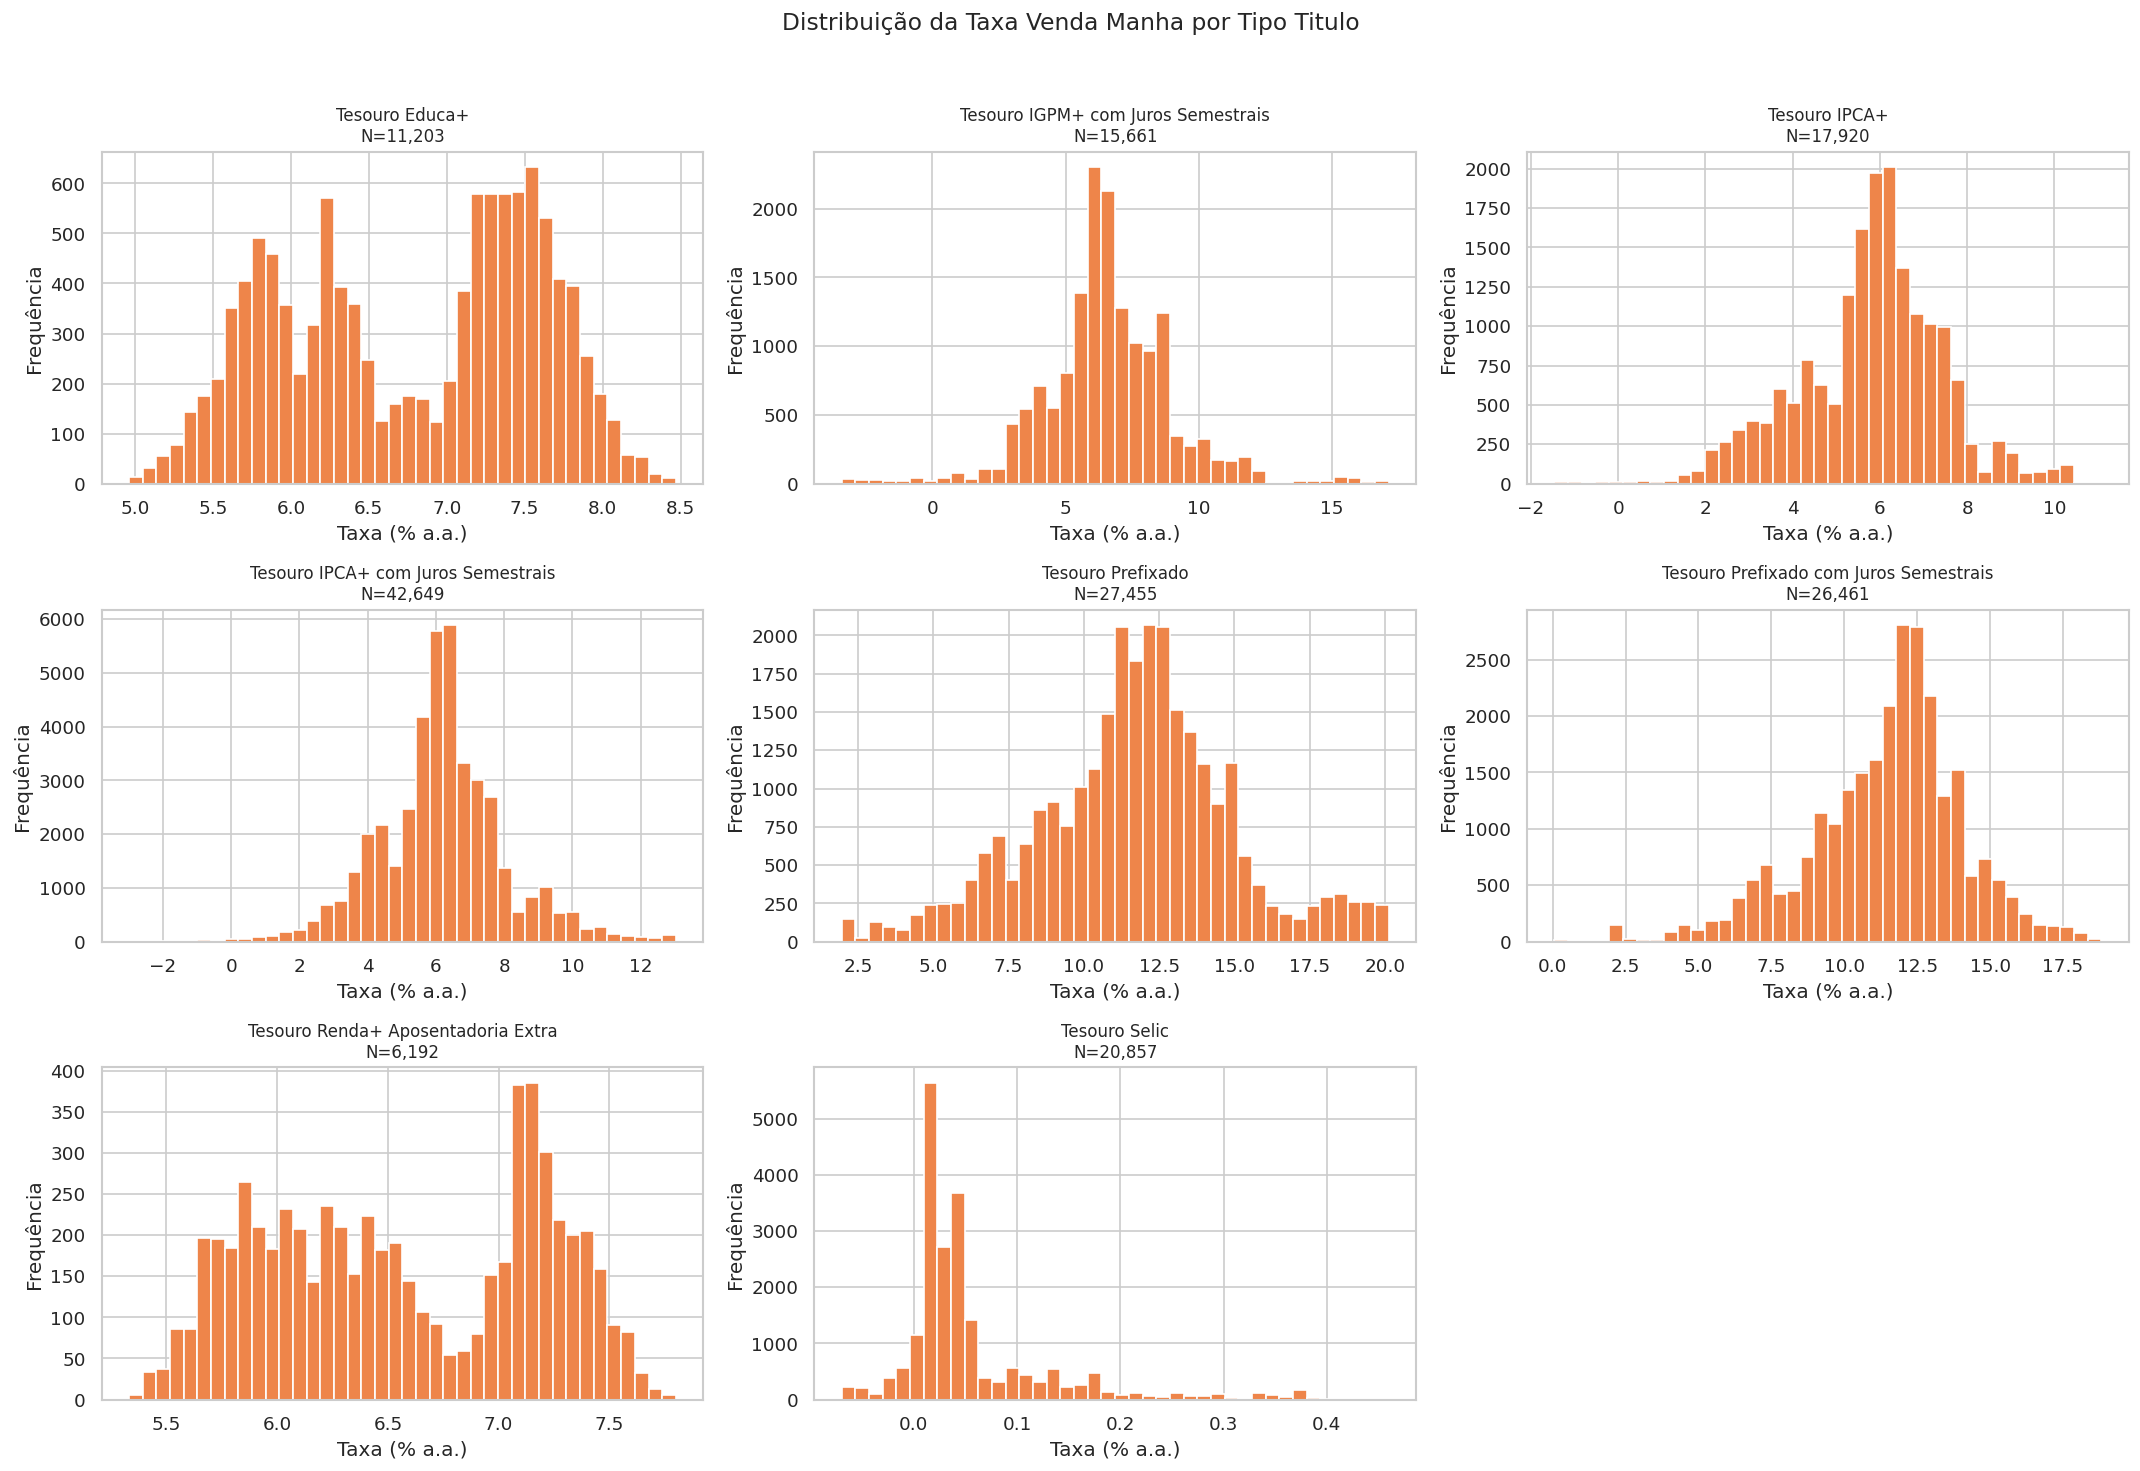

In [ ]:
# Histograma de Taxa Venda Manha por Tipo Titulo

tipos = sorted(df_raw["Tipo Titulo"].dropna().unique())

n_cols = 3
n_rows = int(np.ceil(len(tipos) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = np.array(axes).reshape(-1)

cor = sns.color_palette("muted")[1]

for i, tipo in enumerate(tipos):
    ax = axes[i]
    subset = df_raw.loc[df_raw["Tipo Titulo"] == tipo, "Taxa Venda Manha"].dropna()
    ax.hist(subset, bins=40, color=cor, edgecolor="white")
    ax.set_title(f"{tipo}\nN={len(subset):,}", fontsize=10)
    ax.set_xlabel("Taxa (% a.a.)")
    ax.set_ylabel("Frequência")

# Esconde eixos sobrando (quando grade > quantidade de tipos)
for j in range(len(tipos), len(axes)):
    axes[j].axis("off")

plt.suptitle("Distribuição da Taxa Venda Manha por Tipo Titulo", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Como o titulo `Tesouro Selic` apresenta se muito centrado em valores próximos de zero e sua dispersão é muito baixa, na casa dos centésimos, a presença de truncamento de dados pode distorcer significativamente as análises estatísticas e os modelos preditivos, levando a conclusões errôneas sobre o comportamento das taxas e preços dos títulos. Desta forma se preferirá remover este titulo da análise, pois ele não apresenta segurança suficiente para contribuir com insights relevantes e pode introduzir ruído nos modelos preditivos.

In [ ]:
df_pre = df_raw.loc[~(df_raw['Tipo Titulo'] == 'Tesouro Selic'), :]

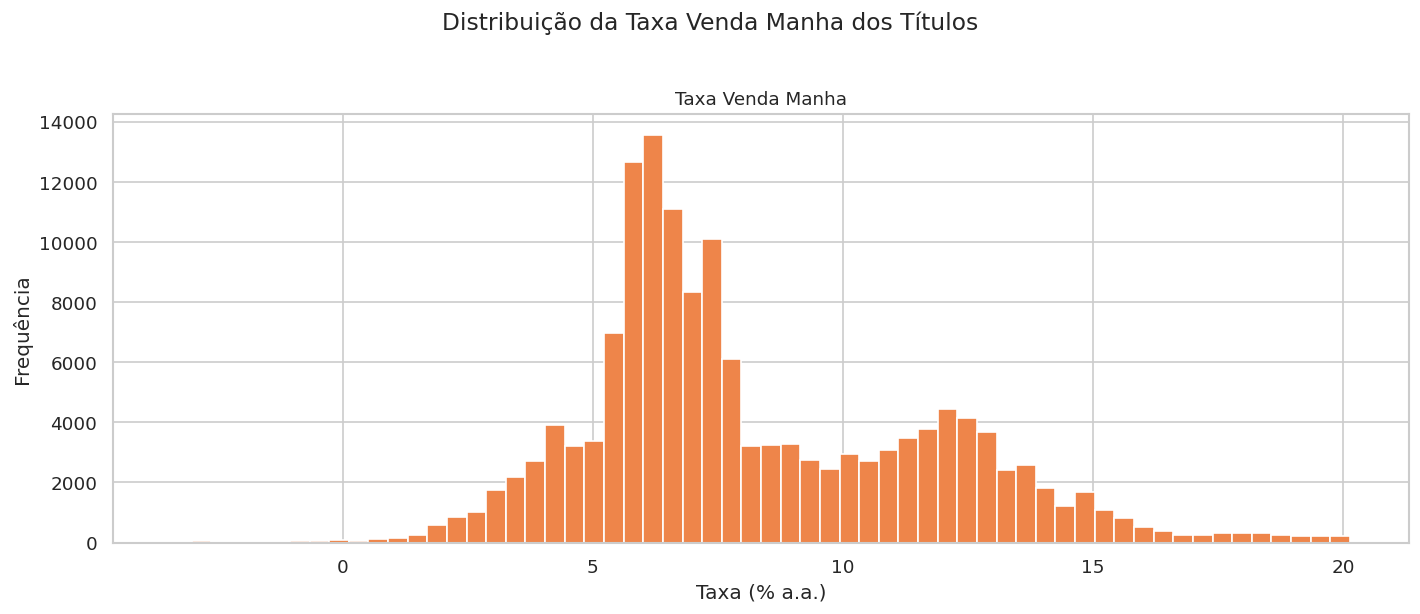

In [ ]:

df_pre["Taxa Venda Manha"].hist(bins=60, color=sns.color_palette("muted")[1], edgecolor="white")
plt.title("Taxa Venda Manha", fontsize=11)
plt.xlabel("Taxa (% a.a.)")
plt.ylabel("Frequência")
plt.suptitle("Distribuição da Taxa Venda Manha dos Títulos", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
colunas_numericas = df_pre.select_dtypes(include="number").columns.tolist()

print("Zeros encontrados nas colunas numéricas:")
for col in colunas_numericas:
    zeros_antes = (df_pre[col] == 0).sum()
    
    # df_pre[col] = df_pre[col].replace(0, np.nan)
    print(f"  {col:25s}: {zeros_antes:5,} zeros")

print(f"\nTotal de NaN após substituição: {df_pre.isnull().sum().sum():,}")

Zeros encontrados nas colunas numéricas:
  Taxa Compra Manha        :    15 zeros → NaN
  Taxa Venda Manha         :     1 zeros → NaN
  PU Compra Manha          :    49 zeros → NaN
  PU Venda Manha           :    48 zeros → NaN
  PU Base Manha            :    29 zeros → NaN

Total de NaN após substituição: 0


A substituição é justificada pelo contexto do domínio: o Tesouro Nacional não negocia títulos com taxa ou preço zero — esses registros indicam que o título não estava disponível para negociação naquele pregão. Convertê-los para `NaN` permite que as funções de análise e modelagem os tratem corretamente como dados ausentes.

### 5.3 Remoção de Registros com Todos os Valores Numéricos Ausentes

In [ ]:
registros_antes = len(df_pre)
df_pre = df_pre.dropna(subset=colunas_numericas, how="all")
registros_depois = len(df_pre)

print(f"Registros antes : {registros_antes:,}")
print(f"Registros depois: {registros_depois:,}")
print(f"Removidos       : {registros_antes - registros_depois:,}")

Registros antes : 147,485
Registros depois: 147,485
Removidos       : 0


Registros onde **todas** as colunas numéricas são NaN não oferecem informação analítica e são removidos. Registros com ausência **parcial** são mantidos — a ausência em algumas colunas pode ser informativa (ex.: título sem taxa de compra mas com taxa de venda).


### 5.4 Engenharia de Atributos

Criamos atributos derivados que podem ser úteis em análises futuras.

In [ ]:
# Dias até o vencimento a partir de cada Data Base
df_pre["dias_ate_vencimento"] = (
    df_pre["Data Vencimento"] - df_pre["Data Base"]
).dt.days

# Spread entre taxa de venda e compra (em pontos percentuais)
df_pre["spread_taxa"] = df_pre["Taxa Venda Manha"] - df_pre["Taxa Compra Manha"]

# Spread percentual entre PU de venda e compra
df_pre["spread_pu"] = df_pre["PU Venda Manha"] - df_pre["PU Compra Manha"]

# Ano e mês de referência (úteis para análises temporais)
df_pre["ano"] = df_pre["Data Base"].dt.year
df_pre["mes"] = df_pre["Data Base"].dt.month

print("Novos atributos criados:")
print(df_pre[["dias_ate_vencimento", "spread_taxa", "spread_pu", "ano", "mes"]].describe().round(4))

Novos atributos criados:
       dias_ate_vencimento  spread_taxa   spread_pu          ano          mes
count          147485.0000  147470.0000  147436.000  147485.0000  147485.0000
mean             3823.7850       0.0879     -14.272    2015.9266       6.5038
std              4152.7639       0.0356      18.096       6.6642       3.4369
min                 1.0000       0.0200    -108.930    2004.0000       1.0000
25%               829.0000       0.0600     -24.080    2010.0000       3.0000
50%              2302.0000       0.1000      -6.080    2016.0000       7.0000
75%              5510.0000       0.1200      -1.580    2023.0000       9.0000
max             22600.0000       0.1200     347.820    2026.0000      12.0000


A criação do atributo `dias_ate_vencimento` é especialmente relevante: o tempo até o vencimento é um fator determinante na precificação de títulos de renda fixa, e futuros modelos preditivos se beneficiarão desse atributo explicitamente calculado.

### 5.5 Dataset Pré-processado — Visão Geral

In [ ]:
print(f"Dimensões do dataset pré-processado: {df_pre.shape}")
print(f"Colunas: {df_pre.columns.tolist()}")
df_pre.head()

Dimensões do dataset pré-processado: (147485, 13)
Colunas: ['Tipo Titulo', 'Data Vencimento', 'Data Base', 'Taxa Compra Manha', 'Taxa Venda Manha', 'PU Compra Manha', 'PU Venda Manha', 'PU Base Manha', 'dias_ate_vencimento', 'spread_taxa', 'spread_pu', 'ano', 'mes']


,Tipo Titulo,Data Vencimento,Data Base,Taxa Compra Manha,Taxa Venda Manha,PU Compra Manha,PU Venda Manha,PU Base Manha,dias_ate_vencimento,spread_taxa,spread_pu,ano,mes
0,Tesouro Prefixado com Juros Semestrais,2013-01-01,2009-11-04,12.42,12.48,975.39,974.00,973.55,1154,0.06,-1.39,2009,11
1,Tesouro Prefixado com Juros Semestrais,2014-01-01,2009-11-04,12.70,12.76,952.60,950.90,950.44,1519,0.06,-1.70,2009,11
2,Tesouro Prefixado com Juros Semestrais,2011-01-01,2009-11-04,10.30,10.34,1030.41,1030.01,1029.60,423,0.04,-0.40,2009,11
3,Tesouro Prefixado com Juros Semestrais,2010-07-01,2009-11-04,9.12,9.16,1039.37,1039.13,1038.77,239,0.04,-0.24,2009,11
4,Tesouro Prefixado com Juros Semestrais,2017-01-01,2009-11-04,13.19,13.25,895.53,893.18,892.74,2615,0.06,-2.35,2009,11


### 5.6 Normalização (Min-Max Scaling)

A normalização Min-Max transforma os valores numéricos para o intervalo [0, 1], preservando a distribuição original dos dados. É útil para algoritmos sensíveis à escala (ex.: KNN, redes neurais, SVM).

In [ ]:
colunas_para_escalar = [
    "Taxa Compra Manha", "Taxa Venda Manha",
    "PU Compra Manha", "PU Venda Manha", "PU Base Manha",
    "dias_ate_vencimento",
]

# Trabalhar apenas com linhas sem NaN nas colunas de escala
df_escala = df_pre[colunas_para_escalar].dropna()

scaler_minmax = MinMaxScaler()
df_normalizado = pd.DataFrame(
    scaler_minmax.fit_transform(df_escala),
    columns=[f"{c}_norm" for c in colunas_para_escalar],
    index=df_escala.index,
)

print("Resumo do dataset normalizado (intervalo esperado: [0, 1]):")
print(df_normalizado.describe().round(4))

Resumo do dataset normalizado (intervalo esperado: [0, 1]):
       Taxa Compra Manha_norm  Taxa Venda Manha_norm  PU Compra Manha_norm  \
count             147435.0000            147435.0000           147435.0000   
mean                   0.4929                 0.4934                0.1867   
std                    0.1458                 0.1459                0.1434   
min                    0.0000                 0.0000                0.0000   
25%                    0.3948                 0.3955                0.0824   
50%                    0.4499                 0.4507                0.1402   
75%                    0.6026                 0.6032                0.2579   
max                    1.0000                 1.0000                1.0000   

       PU Venda Manha_norm  PU Base Manha_norm  dias_ate_vencimento_norm  
count          147435.0000         147435.0000               147435.0000  
mean                0.1873              0.1874                    0.1692  
std         

Após a normalização, todos os valores estão no intervalo [0, 1]. Não há valores fora desse range, confirmando que a transformação foi aplicada corretamente. A normalização é especialmente importante quando combinamos atributos com escalas muito diferentes (como taxas em % e preços em R$).

### 5.7 Padronização (Z-score)

A padronização Z-score transforma os dados para média 0 e desvio-padrão 1. É útil para algoritmos que assumem distribuição gaussiana dos atributos (ex.: regressão logística, LDA).

In [ ]:
scaler_zscore = StandardScaler()
df_padronizado = pd.DataFrame(
    scaler_zscore.fit_transform(df_escala),
    columns=[f"{c}_std" for c in colunas_para_escalar],
    index=df_escala.index,
)

print("Resumo do dataset padronizado (média ≈ 0, desvio-padrão ≈ 1):")
print(df_padronizado.describe().round(4))

Resumo do dataset padronizado (média ≈ 0, desvio-padrão ≈ 1):
       Taxa Compra Manha_std  Taxa Venda Manha_std  PU Compra Manha_std  \
count            147435.0000           147435.0000          147435.0000   
mean                 -0.0000               -0.0000               0.0000   
std                   1.0000                1.0000               1.0000   
min                  -3.3801               -3.3821              -1.3022   
25%                  -0.6724               -0.6711              -0.7273   
50%                  -0.2951               -0.2925              -0.3244   
75%                   0.7526                0.7528               0.4962   
max                   3.4778                3.4726               5.6714   

       PU Venda Manha_std  PU Base Manha_std  dias_ate_vencimento_std  
count         147435.0000        147435.0000              147435.0000  
mean               0.0000            -0.0000                   0.0000  
std                1.0000             1.0000  

Após a padronização, a média de cada coluna é aproximadamente 0 e o desvio-padrão é aproximadamente 1. Os valores mínimo e máximo indicam a magnitude dos outliers em termos de desvios-padrão. Colunas com valores extremos (mín < -3 ou máx > +3) merecem atenção especial em etapas de modelagem.

### 5.8 Discretização das Taxas de Venda

A discretização converte os valores contínuos de taxa em faixas categóricas ordinais. Isso é útil para análises de agrupamento e pode simplificar a interpretação em contextos de negócio.

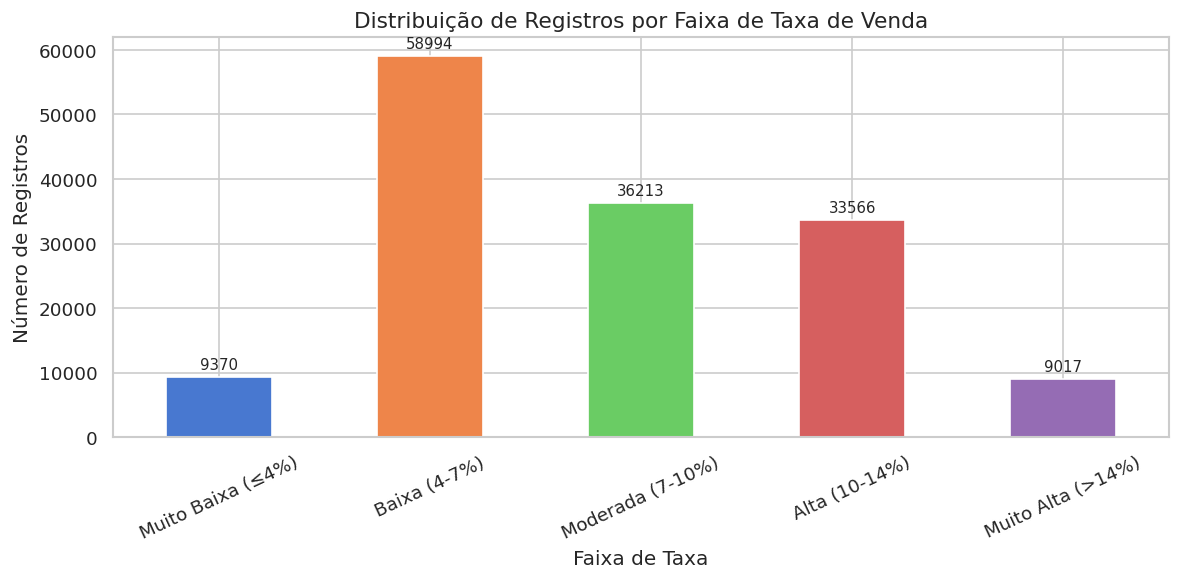

faixa_taxa_venda
Muito Baixa (≤4%)     9370
Baixa (4-7%)         58994
Moderada (7-10%)     36213
Alta (10-14%)        33566
Muito Alta (>14%)     9017


In [ ]:
# Definir faixas baseadas no contexto do mercado brasileiro de renda fixa
faixas = [0, 4, 7, 10, 14, float("inf")]
rotulos = ["Muito Baixa (≤4%)", "Baixa (4-7%)", "Moderada (7-10%)",
           "Alta (10-14%)", "Muito Alta (>14%)"]

df_pre["faixa_taxa_venda"] = pd.cut(
    df_pre["Taxa Venda Manha"],
    bins=faixas,
    labels=rotulos,
    right=True,
)

distribuicao_faixas = df_pre["faixa_taxa_venda"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
distribuicao_faixas.plot(kind="bar", ax=ax, color=sns.color_palette("muted", len(rotulos)))
ax.set_title("Distribuição de Registros por Faixa de Taxa de Venda", fontsize=13)
ax.set_xlabel("Faixa de Taxa")
ax.set_ylabel("Número de Registros")
ax.tick_params(axis="x", rotation=25)
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3, fontsize=9)
plt.tight_layout()
plt.show()

print(distribuicao_faixas.to_string())

**Análise após discretização:**

As faixas foram definidas com base nos patamares relevantes para o investidor de renda fixa no Brasil:

- **Muito Baixa (≤4%):** corresponde a taxas reais próximas de zero, típicas de períodos de juro estruturalmente baixo (2020–2021).
- **Baixa (4–7%):** faixa historicamente associada ao piso do ciclo monetário.
- **Moderada (7–10%):** faixa de equilíbrio histórico para títulos prefixados.
- **Alta (10–14%):** ciclos de aperto monetário mais severos.
- **Muito Alta (>14%):** eventos extremos (crise de 2002, pico de 2015–2016).

A concentração em **Moderada** e **Alta** reflete a realidade de um país com histórico de juros reais elevados.

### 5.9 One-Hot Encoding do Tipo de Título

Transformamos a coluna categórica `Tipo Titulo` em variáveis binárias (dummies). Isso é necessário para a maioria dos algoritmos de aprendizado de máquina, que não aceitam dados categóricos diretamente.

In [ ]:
df_dummies = pd.get_dummies(df_pre["Tipo Titulo"], prefix="titulo", dtype=int)

print(f"Colunas geradas pelo one-hot encoding: {df_dummies.shape[1]}")
print(df_dummies.columns.tolist())
df_dummies.head()

Colunas geradas pelo one-hot encoding: 7
['titulo_Tesouro Educa+', 'titulo_Tesouro IGPM+ com Juros Semestrais', 'titulo_Tesouro IPCA+', 'titulo_Tesouro IPCA+ com Juros Semestrais', 'titulo_Tesouro Prefixado', 'titulo_Tesouro Prefixado com Juros Semestrais', 'titulo_Tesouro Renda+ Aposentadoria Extra']


,titulo_Tesouro Educa+,titulo_Tesouro IGPM+ com Juros Semestrais,titulo_Tesouro IPCA+,titulo_Tesouro IPCA+ com Juros Semestrais,titulo_Tesouro Prefixado,titulo_Tesouro Prefixado com Juros Semestrais,titulo_Tesouro Renda+ Aposentadoria Extra
0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0
2,0,0,0,0,0,1,0
3,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0


In [ ]:
# Dataset final com one-hot encoding integrado (excluindo a coluna original)
df_final = pd.concat(
    [df_pre.drop(columns=["Tipo Titulo"]), df_dummies],
    axis=1,
)

print(f"Dimensões do dataset final: {df_final.shape}")
df_final.head()

Dimensões do dataset final: (147485, 20)


,Data Vencimento,Data Base,Taxa Compra Manha,Taxa Venda Manha,PU Compra Manha,PU Venda Manha,PU Base Manha,dias_ate_vencimento,spread_taxa,spread_pu,ano,mes,faixa_taxa_venda,titulo_Tesouro Educa+,titulo_Tesouro IGPM+ com Juros Semestrais,titulo_Tesouro IPCA+,titulo_Tesouro IPCA+ com Juros Semestrais,titulo_Tesouro Prefixado,titulo_Tesouro Prefixado com Juros Semestrais,titulo_Tesouro Renda+ Aposentadoria Extra
0,2013-01-01,2009-11-04,12.42,12.48,975.39,974.00,973.55,1154,0.06,-1.39,2009,11,Alta (10-14%),0,0,0,0,0,1,0
1,2014-01-01,2009-11-04,12.70,12.76,952.60,950.90,950.44,1519,0.06,-1.70,2009,11,Alta (10-14%),0,0,0,0,0,1,0
2,2011-01-01,2009-11-04,10.30,10.34,1030.41,1030.01,1029.60,423,0.04,-0.40,2009,11,Alta (10-14%),0,0,0,0,0,1,0
3,2010-07-01,2009-11-04,9.12,9.16,1039.37,1039.13,1038.77,239,0.04,-0.24,2009,11,Moderada (7-10%),0,0,0,0,0,1,0
4,2017-01-01,2009-11-04,13.19,13.25,895.53,893.18,892.74,2615,0.06,-2.35,2009,11,Alta (10-14%),0,0,0,0,0,1,0


O one-hot encoding gerou uma coluna binária para cada tipo de título. Ao utilizar esse dataset em modelos lineares, recomenda-se remover uma das colunas (dummy trap) para evitar multicolinearidade perfeita. Para árvores de decisão e modelos baseados em árvores, isso não é necessário.

### 5.10 Análise Revisitada após Pré-processamento

Após o pré-processamento, revisamos a distribuição das taxas para confirmar que as transformações foram aplicadas corretamente e para verificar se surgem novos insights.

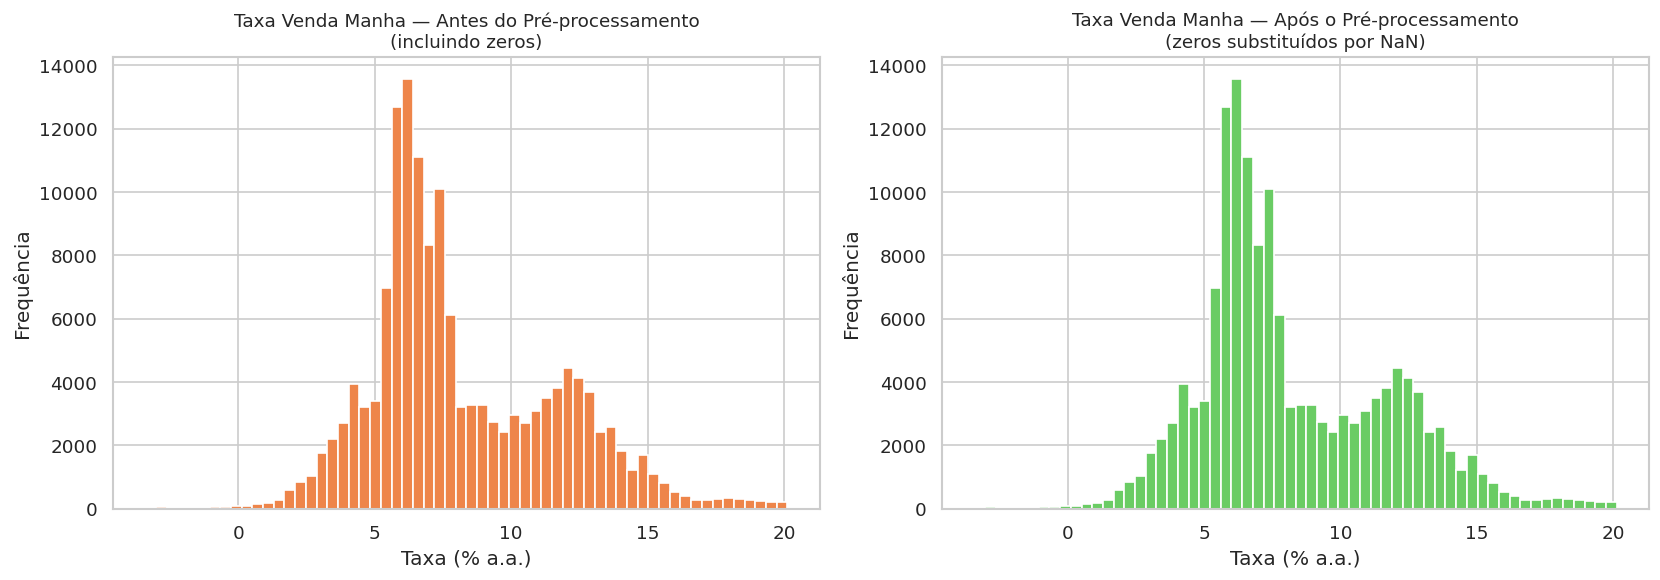

In [ ]:
# Comparar distribuição de taxa antes e após remoção de zeros
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes (com zeros)
df_raw["Taxa Venda Manha"].hist(bins=60, ax=axes[0], color=sns.color_palette("muted")[1], edgecolor="white")
axes[0].set_title("Taxa Venda Manha — Antes do Pré-processamento\n(incluindo zeros)", fontsize=11)
axes[0].set_xlabel("Taxa (% a.a.)")
axes[0].set_ylabel("Frequência")

# Depois (sem zeros)
df_pre["Taxa Venda Manha"].hist(bins=60, ax=axes[1], color=sns.color_palette("muted")[2], edgecolor="white")
axes[1].set_title("Taxa Venda Manha — Após o Pré-processamento\n(zeros substituídos por NaN)", fontsize=11)
axes[1].set_xlabel("Taxa (% a.a.)")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

---
## 4. Análise Exploratória dos Dados (EDA)

### 4.1 Estatísticas Descritivas

In [ ]:
# Cópia de trabalho preservando o dataset original
df = df_raw.iloc[:, 3:8].copy()

# Resumo estatístico das colunas numéricas
desc = df.describe().T
desc["median"] = df.describe(percentiles=[0.5]).T["50%"]
desc["mode"] = df[desc.index].mode().iloc[0]
desc = desc[["count", "mean", "std", "min", "25%", "median", "75%", "max", "mode"]]
desc.columns = ["N", "Média", "Desvio-Padrão", "Mín", "Q1", "Mediana", "Q3", "Máx", "Moda"]
desc

In [ ]:
desc = df.describe().T
desc

In [ ]:
df.describe(percentiles=[0.5]).T

**Análise das Estatísticas Descritivas:**

- As colunas de **taxa** apresentam valores entre 0 e aproximadamente 18% ao ano, refletindo o amplo período histórico do dataset (ciclos de alta e baixa da taxa Selic).
- Os **preços unitários** variam consideravelmente: títulos pós-fixados tendem a ter PU próximo a R$ 10.000, enquanto títulos prefixados e IPCA+ apresentam valores iniciais menores que crescem até o vencimento.
- A presença de valor **mínimo igual a 0** nas colunas de taxa e preço confirma a necessidade de tratamento de valores ausentes disfarçados (zeros).
- A **moda** das taxas e preços não é particularmente informativa dado o comportamento contínuo e evolutivo das séries, porém serve como referência de valor mais frequente no histórico.

### 4.2 Análise de Valores Faltantes e Inconsistentes

In [ ]:
# Valores nulos genuínos
nulos = df.isnull().sum()

# Zeros nas colunas numéricas (valores ausentes mascarados)
colunas_numericas = df.select_dtypes(include="number").columns.tolist()
zeros = (df[colunas_numericas] == 0).sum()

print("Valores nulos por coluna:")
print(nulos.to_string())
print()
print("Zeros nas colunas numéricas (possíveis ausentes mascarados):")
print(zeros.to_string())

**Observações:**

- O dataset não apresenta valores `NaN` nativos, porém contém **zeros** nas colunas numéricas que representam, na prática, ausência de cotação — o título não estava sendo negociado naquele dia.
- Esses registros com zero serão substituídos por `NaN` durante o pré-processamento, permitindo tratamento adequado (remoção ou interpolação).
- A coluna `Tipo Titulo` não apresenta valores ausentes, o que é esperado.

### 4.3 Distribuição dos Tipos de Título

In [ ]:
contagem_tipos = df["Tipo Titulo"].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
contagem_tipos.plot(kind="bar", ax=ax, color=sns.color_palette("muted", len(contagem_tipos)))
ax.set_title("Frequência de Registros por Tipo de Título", fontsize=14)
ax.set_xlabel("Tipo de Título")
ax.set_ylabel("Número de Registros")
ax.tick_params(axis="x", rotation=45)
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3, fontsize=8)
plt.tight_layout()
plt.show()

print(contagem_tipos.to_string())

**Análise:**

O gráfico revela que determinados tipos de título possuem muito mais registros que outros. Títulos mais antigos (como **LTN** e **NTN-B Principal**, nomes anteriores ao rebranding de 2015) apresentam séries históricas mais longas, enquanto os títulos com nomenclatura atual (Tesouro Selic, Tesouro IPCA+, Tesouro Prefixado) têm registros a partir de 2015. O desequilíbrio de frequência entre tipos de título é esperado e reflete principalmente diferenças na janela temporal de oferta de cada produto, e não necessariamente viés nos dados.

### 4.4 Período Coberto pelo Dataset

In [ ]:
data_min = df["Data Base"].min()
data_max = df["Data Base"].max()
periodo = (data_max - data_min).days

print(f"Data mais antiga : {data_min.strftime('%d/%m/%Y')}")
print(f"Data mais recente: {data_max.strftime('%d/%m/%Y')}")
print(f"Período coberto  : {periodo:,} dias ({periodo / 365.25:.1f} anos)")

### 4.5 Distribuição das Taxas de Compra e Venda

Os histogramas a seguir mostram a distribuição geral das taxas de compra e venda da manhã, excluindo os zeros (ausentes mascarados) para não distorcer a análise.

In [ ]:
taxas = df[["Taxa Compra Manha", "Taxa Venda Manha"]].replace(0, np.nan).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, coluna in zip(axes, ["Taxa Compra Manha", "Taxa Venda Manha"]):
    ax.hist(taxas[coluna], bins=60, edgecolor="white", color=sns.color_palette("muted")[0])
    ax.set_title(f"Distribuição: {coluna}", fontsize=13)
    ax.set_xlabel("Taxa (% a.a.)")
    ax.set_ylabel("Frequência")
    ax.axvline(taxas[coluna].mean(), color="red", linestyle="--", label=f"Média: {taxas[coluna].mean():.2f}%")
    ax.axvline(taxas[coluna].median(), color="orange", linestyle="--", label=f"Mediana: {taxas[coluna].median():.2f}%")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Análise:**

As distribuições das taxas de compra e venda apresentam perfil **multimodal**, com concentrações em diferentes faixas de rentabilidade. Isso é esperado num dataset que mistura tipos distintos de título (prefixados, IPCA+, Selic) ao longo de diferentes ciclos econômicos. A **média** é ligeiramente superior à **mediana**, indicando assimetria positiva — há alguns períodos históricos com taxas muito elevadas (ex.: 2015–2016, quando a taxa Selic chegou a 14,25% a.a.) que puxam a média para cima. A semelhança entre as distribuições de compra e venda confirma que o *spread* entre as duas taxas é pequeno.

### 4.6 Distribuição dos Preços Unitários

In [ ]:
pus = df[["PU Compra Manha", "PU Venda Manha", "PU Base Manha"]].replace(0, np.nan).dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, coluna in zip(axes, ["PU Compra Manha", "PU Venda Manha", "PU Base Manha"]):
    ax.hist(pus[coluna], bins=60, edgecolor="white", color=sns.color_palette("muted")[2])
    ax.set_title(f"Distribuição: {coluna}", fontsize=11)
    ax.set_xlabel("Preço (R$)")
    ax.set_ylabel("Frequência")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**Análise:**

As distribuições dos preços unitários são fortemente assimétricas, com cauda longa à direita. A maior concentração de registros ocorre em valores relativamente baixos (próximos a R$ 0–R$ 5.000), com alguns títulos atingindo preços bem mais elevados — especialmente o **Tesouro Selic**, cujo PU cresce continuamente ao longo do tempo, podendo superar R$ 12.000. A assimetria indica que uma transformação logarítmica pode ser útil antes de algoritmos que assumem normalidade nos dados.

### 4.7 Análise por Tipo de Título — Séries Temporais de Taxa de Venda

A evolução temporal das taxas é o principal ângulo analítico deste dataset. Analisamos a **Taxa Venda Manha** separada por tipo de título para capturar os ciclos econômicos.

In [ ]:
# Filtrar apenas registros com taxa válida
df_taxa = df[df["Taxa Venda Manha"] > 0].copy()

# Selecionar os 6 tipos com mais registros para clareza visual
top_tipos = df_taxa["Tipo Titulo"].value_counts().head(6).index.tolist()
df_top = df_taxa[df_taxa["Tipo Titulo"].isin(top_tipos)]

fig, ax = plt.subplots(figsize=(14, 6))
for tipo in top_tipos:
    subset = df_top[df_top["Tipo Titulo"] == tipo].sort_values("Data Base")
    ax.plot(subset["Data Base"], subset["Taxa Venda Manha"], label=tipo, alpha=0.7, linewidth=1)

ax.set_title("Evolução da Taxa de Venda (manhã) por Tipo de Título", fontsize=14)
ax.set_xlabel("Data Base")
ax.set_ylabel("Taxa de Venda (% a.a.)")
ax.legend(fontsize=8, loc="upper right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.1f}%"))
plt.tight_layout()
plt.show()

**Análise:**

A série temporal revela claramente os **ciclos de política monetária** brasileira:

- **2002–2003:** Elevação abrupta das taxas no período pré-eleição presidencial, com o mercado precificando risco político.
- **2006–2012:** Período de relativa estabilidade e gradual queda das taxas, especialmente no governo Lula.
- **2015–2016:** Novo ciclo de alta, com a taxa Selic atingindo 14,25% a.a. em resposta à crise fiscal e recessão.
- **2017–2019:** Queda expressiva após a recessão, com taxas chegando ao menor nível histórico em 2020.
- **2021–2023:** Nova alta acelerada em resposta à inflação pós-pandemia.

Observa-se que o **Tesouro IPCA+** e a **NTN-B** (mesmo produto com nome antigo) apresentam taxas nominalmente menores, pois representam rendimento *real* (acima da inflação), enquanto títulos prefixados e Selic embutem inflação esperada.

### 4.8 Análise de Correlação entre Atributos Numéricos

In [ ]:
# Substituir zeros por NaN antes de calcular correlação
df_corr = df[colunas_numericas].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(
    df_corr.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    mask=mask,
    ax=ax,
    square=True,
    linewidths=0.5,
)
ax.set_title("Matriz de Correlação — Atributos Numéricos", fontsize=13)
plt.tight_layout()
plt.show()

**Análise:**

A matriz de correlação revela padrões importantes:

- **Correlação fortíssima (≈ 1,0) entre PU Compra, PU Venda e PU Base:** os três preços unitários são quase idênticos, diferindo apenas pelo pequeno spread de negociação. Em modelos futuros, utilizar apenas um deles evita multicolinearidade.
- **Correlação fortíssima entre Taxa Compra e Taxa Venda:** assim como os PUs, o spread entre as taxas de compra e venda é mínimo.
- **Correlação negativa entre taxas e preços unitários:** confirma a relação inversa fundamental de renda fixa — quando as taxas sobem, os preços dos títulos caem, e vice-versa. Isso é especialmente relevante para Tesouro IPCA+ e Tesouro Prefixado.

### 4.9 Boxplot das Taxas por Tipo de Título

O boxplot permite comparar a dispersão e os outliers das taxas entre os diferentes tipos de título.

In [ ]:
df_box = df[df["Taxa Venda Manha"] > 0].copy()
# Ordenar por mediana para facilitar a leitura
ordem = (
    df_box.groupby("Tipo Titulo")["Taxa Venda Manha"]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    data=df_box,
    x="Tipo Titulo",
    y="Taxa Venda Manha",
    order=ordem,
    palette="muted",
    ax=ax,
    flierprops={"marker": ".", "alpha": 0.3, "markersize": 3},
)
ax.set_title("Distribuição da Taxa de Venda (manhã) por Tipo de Título", fontsize=13)
ax.set_xlabel("Tipo de Título")
ax.set_ylabel("Taxa de Venda (% a.a.)")
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}%"))
plt.tight_layout()
plt.show()

**Análise:**

O boxplot destaca diferenças estruturais entre os tipos de título:

- **LFT / Tesouro Selic:** apresenta a menor dispersão de taxas, pois é pós-fixado e sua taxa acompanha a Selic diretamente. Os "outliers" correspondem a períodos de estresse no mercado.
- **NTN-F / Tesouro Prefixado:** maior dispersão, refletindo que os preços deste título sofrem com a incerteza sobre a trajetória futura dos juros.
- **NTN-B / Tesouro IPCA+:** mediana de taxa real em torno de 5–7% a.a., com picos em momentos de aversão a risco. A variabilidade é considerável, especialmente para títulos de longo prazo.
- Títulos com nomes mais antigos (LTN, NTN-B Principal) podem ter distribuições distintas por cobrir períodos históricos diferentes.

### 4.10 Análise do Spread entre Taxa de Compra e Venda

In [ ]:
df_spread = df[(df["Taxa Compra Manha"] > 0) & (df["Taxa Venda Manha"] > 0)].copy()
df_spread["spread_taxa"] = df_spread["Taxa Venda Manha"] - df_spread["Taxa Compra Manha"]

# Spread médio por tipo de título
spread_medio = (
    df_spread.groupby("Tipo Titulo")["spread_taxa"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))
spread_medio.plot(kind="bar", ax=ax, color=sns.color_palette("muted")[4])
ax.set_title("Spread Médio entre Taxa de Venda e Taxa de Compra por Tipo de Título", fontsize=13)
ax.set_xlabel("Tipo de Título")
ax.set_ylabel("Spread Médio (p.p.)")
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.2f} p.p."))
plt.tight_layout()
plt.show()

print("Spread médio (pontos percentuais):")
print(spread_medio.round(4).to_string())

**Análise:**

O spread entre as taxas de compra e venda representa o custo implícito de negociação no Tesouro Direto. Os resultados mostram:

- O spread é **muito pequeno** para todos os tipos (geralmente abaixo de 0,10 p.p.), o que evidencia a eficiência e a liquidez razoável do programa.
- Títulos de prazo mais longo tendem a ter spreads ligeiramente maiores, refletindo maior incerteza sobre o valor futuro.
- Picos de spread ocorrem em momentos de stress de mercado, quando a diferença entre oferta e demanda se amplia.

---
## 6. Checklist — Respostas

### Definição do Problema

| Pergunta | Resposta |
|---|---|
| Qual é a descrição do problema? | Analisar o histórico de preços e taxas dos títulos do Tesouro Direto para entender padrões, tendências e comportamento ao longo de ciclos econômicos. |
| Supervisionado ou não supervisionado? | **Não supervisionado** nesta etapa (EDA e pré-processamento); pode ser reformulado como supervisionado para previsão de taxas. |
| Hipóteses/premissas? | Ver Seção 1.3: H1–H4 sobre correlação com macroeconomia, volatilidade por tipo, relação inversa taxa-preço e prêmio por prazo. |
| Restrições para seleção dos dados? | Todos os registros históricos são usados; apenas colunas de período da manhã são analisadas; zeros são tratados como ausentes. |
| Atributos definidos? | Ver Seção 1.5: 8 atributos originais + 6 derivados criados no pré-processamento. |

### Análise de Dados

| Pergunta | Resposta |
|---|---|
| Quantos atributos e instâncias? | Verificado na Seção 3.1 (dimensões do dataset). |
| Tipos de dados? | `Data Base` e `Data Vencimento`: datetime; `Tipo Titulo`: object; demais: float64. |
| Primeiras linhas chamam atenção? | Zeros nas colunas numéricas indicam ausentes mascarados; dois sistemas de nomenclatura (pré e pós-2015). |
| Valores faltantes/discrepantes? | Zeros mascarando ausências (tratados na Seção 5.2); nenhum NaN nativo no dataset original. |
| Resumo estatístico realizado? | Sim — Seção 4.1. |
| Distribuição de cada atributo? | Sim — Seções 4.3 (categórico), 4.5 (taxas), 4.6 (PUs). |
| Análise individual e combinada? | Sim — séries temporais (4.7), correlação (4.8), boxplot (4.9), spread (4.10). |

### Pré-processamento

| Operação | Realizada? | Seção |
|---|---|---|
| Substituição de zeros por NaN | ✅ | 5.2 |
| Remoção de registros completamente ausentes | ✅ | 5.3 |
| Engenharia de atributos | ✅ | 5.4 |
| Normalização (Min-Max) | ✅ | 5.6 |
| Padronização (Z-score) | ✅ | 5.7 |
| Discretização de taxas | ✅ | 5.8 |
| One-hot encoding | ✅ | 5.9 |
| Análise revisitada | ✅ | 5.10 |

---
## 7. Conclusão

Este trabalho percorreu as principais etapas de um projeto de ciência de dados aplicado ao dataset de **Taxas dos Títulos Ofertados pelo Tesouro Direto**.

### Principais Achados

1. **Ciclos econômicos bem visíveis:** a série histórica reflete com fidelidade os ciclos de política monetária brasileira, com altas expressivas em 2002–2003, 2015–2016 e 2021–2022.

2. **Ausentes mascarados:** o dataset não possui NaN nativos, mas contém zeros que representam dias sem negociação. O tratamento correto desses valores é fundamental para qualquer análise subsequente.

3. **Correlação inversa taxa × preço:** confirmada na matriz de correlação, esta relação é estrutural em renda fixa e deve ser considerada em qualquer modelo preditivo.

4. **Alta colinearidade entre PUs:** os três preços unitários (compra, venda, base) são quase redundantes. Em etapas de modelagem, recomenda-se utilizar apenas um deles.

5. **Diversidade de títulos:** o dataset mistura produtos com características e históricos distintos, exigindo análises segmentadas por tipo de título para conclusões válidas.

### Próximos Passos

- **Modelagem preditiva:** com os dados pré-processados, é possível construir modelos para prever a taxa de um título em função de características como prazo, tipo e momento econômico (ex.: regressão linear, gradient boosting).
- **Análise de cluster:** identificar grupos de títulos com comportamentos similares de taxa ao longo do tempo.
- **Análise de sazonalidade:** investigar se há padrões mensais ou anuais nas taxas dos títulos.
- **Integração com dados macroeconômicos:** combinar com séries históricas da Selic, IPCA e PIB para enriquecer a análise causal.

---
*Notebook desenvolvido para a disciplina Análise de Dados e Boas Práticas — Especialização em Ciência de Dados, PUC. Todos os dados são públicos e disponibilizados pelo Tesouro Nacional.*